# Seminar on Financial Econometrics

Student: Gabriel Sánchez-Hernández, MatNr. 4759079

Summer Semester, 2026

Professor: Christian Conrad, Ph.D.

Tutor: Lara Schadwinkel, M.Sc.

This notebook is built to be `self-contained and reproducible`: run it top to bottom on the `finmet` folder and every result regenerates from the size-reduced parquet files under `../data`.

In [1]:
# Imports
import importlib
import json
import subprocess
import sys
from datetime import date
from pathlib import Path

REQUIREMENTS = Path("../requirements.txt")

IMPORTS = [
    ("polars",                  "pl"),
    ("pyarrow",                 "pa"),
    ("pandas",                  "pd"),
    ("numpy",                   "np"),
    ("matplotlib.pyplot",       "plt"),
    ("seaborn",                 "sns"),
    ("pandas_market_calendars", "mcal"),
    ("yfinance",                "yf"),
]

def _import_all():
    for module, alias in IMPORTS:
        globals()[alias] = importlib.import_module(module)

try:
    _import_all()
except (ImportError, ValueError):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(REQUIREMENTS)], check=True)
    _import_all()

print("ready:", [alias for _, alias in IMPORTS])

ready: ['pl', 'pa', 'pd', 'np', 'plt', 'sns', 'mcal', 'yf']


## Data

Quotations data are downloaded from DataBento and correspond to `BBO on interval (BBO)` from the `Nasdaq TotalView-ITCH` database:

BBO on interval (BBO) provides the last best bid, best offer, and sale at `1-second` intervals.

Databento adopts the following convention for BBO:

- If no trade or BBO update occurs within the interval, no record is printed.
- If a BBO update occurs but no trade takes place within the interval, the last sale information is forward-filled from the previous interval.
- If no BBO update occurs but a trade takes place within the interval, the BBO information is forward-filled from the previous interval.

The Databento databases are originally in .dbn format and are about 2GB each for the selected period. For efficient storage practices, I conduct a pre-processing as follows:
1. Convert the databento `.dbn.zst` to parquet;
2. Keep `ts_event, size, bid, ask`, add a `date` column, convert to `America/New_York`, keep only regular-session events (09:30–16:00), drop nulls;
3. Write the result back as a `minimal-size parquet` (`zstd`), replacing the raw file.

Each equity lives in `../data/<TICKER>/<TICKER>.parquet` as a size-reduced BBO series (columns `ts_event` in *America/New_York*, `bid`, `ask`, `date`).

## Clean-Up

I use data from the (to the date) components of the Dow Jones Industrial Average (DJI) index `plus` three Exchange Trade Funds (ETFs): DIA, SPY, and QQQ.

The loop below opens every ticker in `TICKERS` as a **lazy** frame (`pl.scan_parquet`) in the `data` dictionary. Nothing is read into memory until a query is `collect`-ed, so the whole cross-section stays tractable. Each analysis below loops over `data`, collecting only the small result it needs.

In [2]:
# Importing the data
DATA_DIR = Path("../data")
TABLES_DIR = Path("../tables")
FIGURES_DIR = Path("../figures")
for _d in (TABLES_DIR, FIGURES_DIR):
    _d.mkdir(parents=True, exist_ok=True)

TICKERS  = ["AAPL", "AMGN", "AMZN", "AXP", "BA", "CAT", "CRM", "CSCO", "CVX", "DIS",
            "GOOGL", "GS", "HD", "HON", "IBM", "JNJ", "JPM", "KO", "MCD", "MMM",
            "MRK", "MSFT", "NKE", "NVDA", "PG", "SHW", "TRV", "UNH", "V", "WMT",
            "SPY", "QQQ", "DIA"]
TICKERS_BY_SECTOR = {
    "ETFs": ["SPY", "QQQ", "DIA"],
    "Technology": ["AAPL", "CRM", "CSCO", "IBM", "MSFT", "NVDA"],
    "Healthcare": ["AMGN", "JNJ", "MRK", "UNH"],
    "Consumer Cyclical": ["AMZN", "HD", "MCD", "NKE"],
    "Financial Services": ["AXP", "GS", "JPM", "TRV", "V"],
    "Industrials": ["BA", "CAT", "HON", "MMM"],
    "Energy": ["CVX"],
    "Communication": ["DIS", "GOOGL"],
    "Consumer Defensive": ["KO", "PG", "WMT"],
    "Materials": ["SHW"]
}

START, END = date(2018, 5, 1), date(2026, 6, 30)
MAX_REL_SPREAD = 0.05 

_sched = mcal.get_calendar("NASDAQ").schedule(start_date=START, end_date=END)
_close = _sched["market_close"].dt.tz_convert("America/New_York")
HALF_DAYS = {ts.date() for ts, c in zip(_sched.index, _close) if c.hour < 16}
print(f"half-days to drop: {len(HALF_DAYS)}")

data = {
    tick: pl.scan_parquet(DATA_DIR / tick / f"{tick}.parquet")
            .filter(pl.col("date").is_between(START, END))
            .filter(pl.col("bid") > 0)
            .filter(pl.col("ask") > 0)
            .filter(pl.col("bid") <= pl.col("ask"))
            .filter((pl.col("ask") - pl.col("bid"))
                    <= MAX_REL_SPREAD * (pl.col("bid") + pl.col("ask")) / 2)
            .filter(~pl.col("date").is_in(list(HALF_DAYS)))
    for tick in TICKERS
}

summary = pl.concat([
    lf.select(
        pl.lit(tick).alias("ticker"),
        pl.len().alias("rows"),
        pl.col("date").n_unique().alias("days"),
        pl.col("date").min().alias("start"),
        pl.col("date").max().alias("end"),
    ).collect()
    for tick, lf in data.items()
])

print(summary)

half-days to drop: 18
shape: (33, 5)
┌────────┬──────────┬──────┬────────────┬────────────┐
│ ticker ┆ rows     ┆ days ┆ start      ┆ end        │
│ ---    ┆ ---      ┆ ---  ┆ ---        ┆ ---        │
│ str    ┆ u32      ┆ u32  ┆ date       ┆ date       │
╞════════╪══════════╪══════╪════════════╪════════════╡
│ AAPL   ┆ 46391887 ┆ 2034 ┆ 2018-05-01 ┆ 2026-06-30 │
│ AMGN   ┆ 21283260 ┆ 2034 ┆ 2018-05-01 ┆ 2026-06-30 │
│ AMZN   ┆ 40410585 ┆ 2034 ┆ 2018-05-01 ┆ 2026-06-30 │
│ AXP    ┆ 25998987 ┆ 2034 ┆ 2018-05-01 ┆ 2026-06-30 │
│ BA     ┆ 27066931 ┆ 2034 ┆ 2018-05-01 ┆ 2026-06-30 │
│ …      ┆ …        ┆ …    ┆ …          ┆ …          │
│ V      ┆ 31492651 ┆ 2034 ┆ 2018-05-01 ┆ 2026-06-30 │
│ WMT    ┆ 33216159 ┆ 2034 ┆ 2018-05-01 ┆ 2026-06-30 │
│ SPY    ┆ 47330359 ┆ 2034 ┆ 2018-05-01 ┆ 2026-06-30 │
│ QQQ    ┆ 47373090 ┆ 2034 ┆ 2018-05-01 ┆ 2026-06-30 │
│ DIA    ┆ 45556910 ┆ 2034 ┆ 2018-05-01 ┆ 2026-06-30 │
└────────┴──────────┴──────┴────────────┴────────────┘


In [4]:
summary['rows'].sum()

1050972048

### Corporate actions: splits & dividends

The raw quotes are **not** adjusted for corporate actions. Using `yfinance` (`Ticker.splits` / `Ticker.dividends`), I pull each stock's splits and dividends, tabulate them, and build a cumulative **back-adjustment factor** that is applied to `bid`/`ask`.

- **Stock splits**: A stock split happens when a company divides its stock into multiple shares, effectively lowering the price of each share without changing the company's market value. More info: https://www.investopedia.com/terms/s/stocksplit.asp.

Splits rescale every quote multiplicatively on the ex-date (e.g. WMT 3:1 in 2024).

- **Spinoffs**: A spinoff is a type of corporate realignment involving the separation of a division to form a new independent corporation. More info: https://www.investopedia.com/terms/s/spin-out.asp.

`yfinance` also encodes **spinoffs** (MMM → Solventum, MRK → Organon) as *fractional* split ratios, so the same factor corrects them.
- **Dividends**: Dividends are periodic payments made to shareholders from corporate profits. More info: https://www.investopedia.com/terms/d/dividend.asp.

Dividends knock the price down by ~the cash amount on each ex-date; the total-return factor adds them back.

The pull is cached to `../data/corporate_actions.json`, so the notebook reproduces offline and the cache travels with the folder. Only overnight / close-to-close returns need this correction.

In [3]:
# File, to not need internet to replicate splits/dividends tables
CA_CACHE = DATA_DIR / "corporate_actions.json"
actions = json.load(open(CA_CACHE)) if CA_CACHE.exists() else {"_meta": {"source": "yfinance"}}

missing = [t for t in TICKERS if t not in actions]
if missing:
    if yf is None:
        raise RuntimeError(f"{len(missing)} tickers not cached and yfinance unavailable: {missing}")
    for tick in missing:
        tk = yf.Ticker(tick)
        actions[tick] = {
            "splits":    {str(d.date()): float(k)          for d, k in tk.splits.items()},
            "dividends": {str(d.date()): round(float(v), 6) for d, v in tk.dividends.items()},
        }
    actions["_meta"] = {"source": "yfinance", "fetched": str(date.today())}
    json.dump(actions, open(CA_CACHE, "w"), indent=1)
    print(f"fetched {len(missing)} new ticker(s) from yfinance -> {CA_CACHE.name}")
else:
    print(f"corporate actions cache covers all {len(TICKERS)} tickers") # This should be the normal case (no missing tickers in cache)

def act(tick): # Get the cached splits & dividends for `tick`, restricted to the [START, END] window
    a = actions.get(tick, {"splits": {}, "dividends": {}})
    keep = lambda k: START <= date.fromisoformat(k) <= END # Keep a date (k) (YYYY-MM-DD) inside the window of interest
    return {"splits":    {k: v for k, v in a.get("splits", {}).items()    if keep(k)},
            "dividends": {k: v for k, v in a.get("dividends", {}).items() if keep(k)}} # Return splits and dividends

# Splits / spinoffs
split_rows = [
    {"ticker": t,
     "ex_date": d,
     "ratio": round(k, 4),
     "event": f"{k:g}:1 split" if k >= 2 else f"spinoff (price x{1/k:.3f})"} # Splits are integers>=2, and spinoffs are fractions <1 (e.g., 0.5 for a 1-for-2 spinoff)
    for t in TICKERS for d, k in act(t)["splits"].items() # For a specific tick (t), get date (d), ratio (k) [2.0 if 2-for-1 split, 0.5 if 1-for-2 spinoff, etc.]
]
splits_tbl = (pl.DataFrame(split_rows).sort("ex_date")
              if split_rows else pl.DataFrame({"info": ["no splits/spinoffs in TICKERS"]}))
print("\nSplits or spinoffs in sample:")
print(splits_tbl)

# Dividend summary
div_rows = [
    {"ticker": t, "n_dividends": len(act(t)["dividends"]),
     "total_$/share": round(sum(act(t)["dividends"].values()), 2)}
    for t in TICKERS if act(t)["dividends"]
]
div_tbl = (pl.DataFrame(div_rows).sort("ticker")
           if div_rows else pl.DataFrame({"info": ["no dividends in TICKERS"]}))
print("\nDividend summary in sample:")
print(div_tbl)

corporate actions cache covers all 1 tickers

Splits or spinoffs in sample:
shape: (1, 4)
┌────────┬────────────┬───────┬───────────┐
│ ticker ┆ ex_date    ┆ ratio ┆ event     │
│ ---    ┆ ---        ┆ ---   ┆ ---       │
│ str    ┆ str        ┆ f64   ┆ str       │
╞════════╪════════════╪═══════╪═══════════╡
│ AAPL   ┆ 2020-08-31 ┆ 4.0   ┆ 4:1 split │
└────────┴────────────┴───────┴───────────┘

Dividend summary in sample:
shape: (1, 3)
┌────────┬─────────────┬───────────────┐
│ ticker ┆ n_dividends ┆ total_$/share │
│ ---    ┆ ---         ┆ ---           │
│ str    ┆ i64         ┆ f64           │
╞════════╪═════════════╪═══════════════╡
│ AAPL   ┆ 33          ┆ 7.39          │
└────────┴─────────────┴───────────────┘


In [4]:
# Adjustment factor
def adjustment_factor(tick, raw_lf):
    sp = {date.fromisoformat(k): v for k, v in act(tick)["splits"].items()}
    dv = {date.fromisoformat(k): v for k, v in act(tick)["dividends"].items()}

    dc = (raw_lf.filter((pl.col("bid") > 0) & (pl.col("ask") >= pl.col("bid")))
                .group_by("date").agg(((pl.col("bid") + pl.col("ask")) / 2).last().alias("c"))
                .sort("date").collect())
    dates, close = dc["date"].to_list(), dc["c"].to_list()

    sds = sorted(sp)
    S = [float(np.prod([1.0 / sp[s] for s in sds if d < s])) for d in dates]   # split/spinoff factor
    cadj = [c * s for c, s in zip(close, S)]                                   # split-adjusted close
    prev = {dates[i]: cadj[i - 1] for i in range(1, len(dates))}
    dfac = {e: 1.0 - dv[e] / prev[e] for e in sorted(dv) if prev.get(e, 0) > 0}
    eds = sorted(dfac)
    Dv = [float(np.prod([dfac[e] for e in eds if d < e])) for d in dates]      # dividend factor
    return pl.DataFrame({"date": dates, "adj": [s * v for s, v in zip(S, Dv)]})


def raw_window(tick):
    return (pl.scan_parquet(DATA_DIR / tick / f"{tick}.parquet")
              .filter(pl.col("date").is_between(START, END))
              .filter(pl.col("bid") <= pl.col("ask"))
              .filter((pl.col("ask") - pl.col("bid")) <= MAX_REL_SPREAD * (pl.col("bid") + pl.col("ask")) / 2)
              .filter(~pl.col("date").is_in(list(HALF_DAYS))))


# After this, data[tick] is the corrected lazy frame
for tick in TICKERS:
    raw = raw_window(tick)
    fac = adjustment_factor(tick, raw)
    data[tick] = (
        raw.join(fac.lazy(), on="date", how="left")
           .with_columns(pl.col("adj").fill_null(1.0))
           .with_columns((pl.col("bid") * pl.col("adj")).alias("bid"),
                         (pl.col("ask") * pl.col("adj")).alias("ask"))
           .drop("adj")
    )

def _overnight_on(lf, ex):
    return (lf.group_by("date").agg(pl.col("bid").filter(pl.col("bid") > 0).last().alias("c")).sort("date")
              .with_columns((pl.col("c").log() - pl.col("c").shift(1).log()).alias("r"))
              .filter(pl.col("date") == ex).collect())

checks = []
for tick in TICKERS:
    for d in act(tick)["splits"]:
        ex = date.fromisoformat(d)
        rr = _overnight_on(raw_window(tick), ex)
        ra = _overnight_on(data[tick], ex)
        if rr.height and ra.height:
            checks.append({"ticker": tick, "ex_date": d,
                           "overnight_raw": round(rr["r"][0], 4),
                           "overnight_corrected": round(ra["r"][0], 4)})
print("applied split/spinoff + dividend back-adjustment to `data` (files untouched)")
print(pl.DataFrame(checks) if checks else "no splits/spinoffs among current TICKERS")

applied split/spinoff + dividend back-adjustment to `data` (files untouched)
shape: (1, 4)
┌────────┬────────────┬───────────────┬─────────────────────┐
│ ticker ┆ ex_date    ┆ overnight_raw ┆ overnight_corrected │
│ ---    ┆ ---        ┆ ---           ┆ ---                 │
│ str    ┆ str        ┆ f64           ┆ f64                 │
╞════════╪════════════╪═══════════════╪═════════════════════╡
│ AAPL   ┆ 2020-08-31 ┆ -1.3541       ┆ 0.0322              │
└────────┴────────────┴───────────────┴─────────────────────┘


### Sampling Times

Seconds between consecutive quotes, computed **per trading day** (so overnight gaps don't count). Large gaps flag trading halts / circuit breakers or thin liquidity.

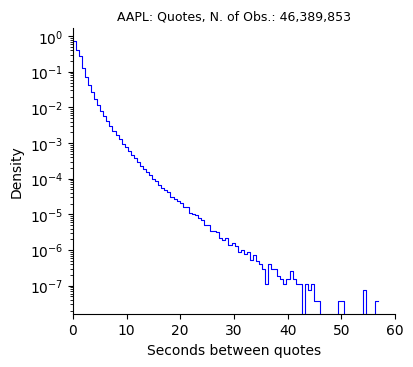

ticker,obs,median_s,p99_s,max_s,gaps>60s
str,i64,f64,f64,f64,i64
"""AAPL""",46389853,0.828,6.18,901.7,5


In [6]:
# Sampling times
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

nrows, ncols = 7, 5
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 24))
axf = axes.flatten()
delta_summary = []


def _draw_sampling(ax, vals, title, lw):
    sns.histplot(vals, bins=100, stat="density", element="step", fill=False,
                 color="blue", linewidth=lw, ax=ax)
    ax.set_yscale("log")
    ax.set_xlim(0, 60)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Seconds between quotes")
    ax.set_ylabel("Density")


for i, tick in enumerate(TICKERS):
    dsec = (
        data[tick]
        .sort("ts_event")
        .with_columns((pl.col("ts_event").diff().over("date").dt.total_nanoseconds() / 1e9).alias("delta_sec"))
        .drop_nulls("delta_sec")
        .select("delta_sec")
        .collect()["delta_sec"]
    )
    n_obs = dsec.len()
    delta_summary.append({
        "ticker": tick, "obs": n_obs,
        "median_s": round(dsec.median(), 3),
        "p99_s": round(dsec.quantile(0.99), 2),
        "max_s": round(dsec.max(), 1),
        "gaps>60s": int((dsec > 60).sum()),
    })
    vals  = dsec.filter(dsec <= 60).to_numpy()
    title = f"{tick}: Quotes, N. of Obs.: {n_obs:,}"

    _draw_sampling(axf[i], vals, title, 0.8)

    figi, axi = plt.subplots(figsize=(6, 4))
    _draw_sampling(axi, vals, title, 1.0)
    sns.despine(fig=figi)
    figi.tight_layout()
    figi.savefig(FIGURES_DIR / f"{tick}_sampling.pdf")
    plt.close(figi)
    del dsec, vals

for j in range(len(TICKERS), nrows * ncols):
    axf[j].set_visible(False)
sns.despine(fig=fig)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "ALL_sampling.pdf")
plt.show()

pl.DataFrame(delta_summary)

I use the `previous-tick interpolation` (Wasserfallen) to obtain regular $\Delta$ s:
1. If there is no change over several minutes, the last quotation is inserted
at every minute since this is the price actually in effect.
2. If more than one rate is recorded in the same minute, the arithmetic
mean is chosen for that specific minute. This procedure creates a
tendency towards first-order autocorrelation. The number of cases in this
category is, however, small.
3. If there is no new quotation in a minute after a minute with several ones,
the last rate is selected.

### Marginal distribution of returns by sampling step

I resample the mid-quote, take `intraday log-returns` $y_{i,m}$ at each $\Delta \in$ `FREQS`, standardize them to unit variance, and plot their density (log scale) against a standard normal $N(0,1)$.

The classic stylized fact: high-frequency returns are strongly **leptokurtic** (sharp peak, fat tails well above the normal) and drift toward Gaussian as $\Delta$ grows.

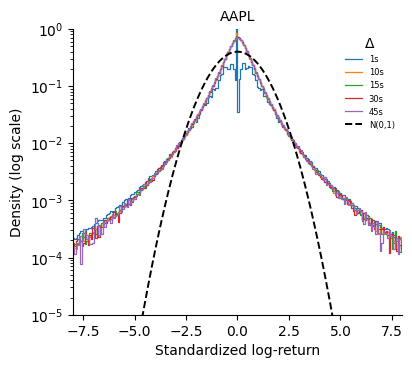

In [17]:
# Marginal distribution
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
FREQS = ["1s", "10s", "15s", "30s", "45s"]


def prev_tick_returns(lf, freq):
    """Intraday log-returns on a regular Δ=`freq` grid via previous-tick interpolation (rules a-c).
    The tick -> bin reduction is streamed off disk (out-of-core); only the small bar table is held."""
    bars = (
        lf.filter((pl.col("bid") > 0) & (pl.col("ask") >= pl.col("bid")))     # drop crossed / non-positive
          .with_columns(((pl.col("bid") + pl.col("ask")) / 2).alias("mid"),
                        pl.col("ts_event").dt.truncate(freq).alias("t"))
          .group_by("date", "t").agg(pl.col("mid").mean())                    # (b) mean of quotes in a bin
          .sort("date", "t")
          .collect(engine="streaming")                                        # streamed reduction
    )
    bars = (bars.upsample("t", every=freq, group_by="date", maintain_order=True)   # regular grid per day
                .with_columns(pl.col("mid").forward_fill().over("date")))          # (a),(c) carry last forward
    return (bars.with_columns(pl.col("mid").log().diff().over("date").alias("r"))   # intraday log-returns
                .drop_nulls("r"))["r"].to_numpy()


xg = np.linspace(-8, 8, 400)
normal_pdf = np.exp(-xg ** 2 / 2) / np.sqrt(2 * np.pi)     # N(0,1): the matched-variance normal

nrows, ncols = 7, 5
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 24))
axf = axes.flatten()

for i, tick in enumerate(TICKERS):
    zs = {}
    for freq in FREQS:                                    # standardize once per (ticker, freq)
        r = prev_tick_returns(data[tick], freq)
        zs[freq] = (r - r.mean()) / r.std()

    def _draw(ax):
        for freq in FREQS:
            sns.histplot(zs[freq], bins=220, binrange=(-8, 8), stat="density", element="step",
                         fill=False, linewidth=0.9, label=freq, ax=ax)
        ax.plot(xg, normal_pdf, "k--", lw=1.4, label="N(0,1)")
        ax.set_yscale("log")
        ax.set_xlim(-8, 8)
        ax.set_ylim(1e-5, 1)
        ax.set_title(tick, fontsize=10)
        ax.set_xlabel("Standardized log-return")
        ax.set_ylabel("Density (log scale)")
        ax.legend(frameon=False, fontsize=6, title="Δ")

    _draw(axf[i])                                          # (a) panel in the combined grid

    figi, axi = plt.subplots(figsize=(6, 4))              # (b) standalone -> TICKER_dist.pdf
    _draw(axi)
    sns.despine(fig=figi)
    figi.tight_layout()
    figi.savefig(FIGURES_DIR / f"{tick}_dist.pdf")
    plt.close(figi)
    del zs

for j in range(len(TICKERS), nrows * ncols):
    axf[j].set_visible(False)
sns.despine(fig=fig)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "ALL_dist.pdf")
plt.show()

## Realized Variance

- **Log** efficient price process: $$\{p^*(t)\}_{t\in [0,\infty)}$$

where $t$ is time, and integer values of $t$ represent market closing times (4:00pm NY). Unit of time: trading day (Monday-Friday 9:30-16:00)
- Observed price process: $$p=p^*+u$$
- Return on day $t$: $$r_t \equiv p(t)-p(t-1)$$
- Integrated variance (the target of estimation): $$IV_{[a,b]} \equiv \int_a^b \sigma^2(s)\,ds$$ Realized variance estimates $IV$: for the *efficient* price $p^*$, $RV^{(\Delta)}_{[a,b]} \xrightarrow{p} IV_{[a,b]}$ as $\Delta\to 0$; but the observation noise $u$ biases it (see below).
- Variance at sampling: $$RV_{[a,b]}^\Omega = \sum_{i=1}^m \{p(t_i)-p(t_{i-1})\}^2$$
with times $a=t_0 < t_1 < ... < t_m = b$ and partition $\Omega=\{t_0,...,t_m\}$. We have $m+1$ price observations, so $m$ objects in the sum. Note that this does not imply equidistant returns (i.e. $t_i-t_{i-1}$ not the same for all $i$). In an interval $[a,b]$ we can have many different RVs, one per partition.
- If the intraday returns are *equidistant* ($t_i-t_{i-1}$ the same for all $i$) where $t_i = t_{i-1}+\Delta$ and $$\Delta \equiv (b-a)/m \iff m\equiv(b-a)/\Delta$$ then the intraday returns are $y_{i,m}=p(t_i)-p(t_i-\Delta)$ and the `regular variance`: $$ RV_{[a,b]}^{(\Delta)}=\sum_{i=1}^m y_{i,m}^2$$ I index the estimator by the grid step $\Delta$ (more intuitive than $m$), while the sum still runs over the $m=(b-a)/\Delta$ equidistant returns.
- Example if there are only two observations ($m=1$): $[a,b]=[9:30:05, 9:30:10]$ then $$\Delta = (5s)/1=5sec$$ 
- The higher the `sampling frequency` (i.e. the more observations we have in [a,b], i.e. the lower $\Delta$, the larger $m$), the more `autocorrelated` the intraday returns are. 
- The authors define a Newey-West-based estimator using the Bartlett kernel, defined as:
$$RV^{(\Delta)}_{NW[a,b]} \equiv RV_{[a,b]}^{(\Delta)} + 2\sum_{h=1}^q \left(1-\frac{h}{q+1}\right)\sum_{i=1}^{m-h}y_{i,m}y_{i+h,m}$$
where $h$ = a lag distance (how many intervals apart two returns are) and $q$ = the maximum included lag. Hansen & Lunde set $q$ so that $q\times\Delta\approx 10$ min.

### (1) Original Hansen-Lunde

H-L mix two measures
1. Overnight returns $r^2_{1,t}$ constructed as the log difference between the first price (mid-quote) of the day and the last price (mid-quote) of the previous day.
2. High-Frequency intraday returns: $RV_{2,t}$ estimated with $\hat{RV_{2,t}}\equiv (1/2)RV_{NW[a,b], ASK}^{(\Delta = 60s)} + (1/2)RV_{NW[a,b], BID}^{(\Delta = 60s)}$

to construct an estimator of the IV: $$RV_t(\omega)=\omega_1 r^2_{1,t}+\omega_2 RV_{2,t}$$

The solution is given by $$\omega_1^*\equiv(1-\phi)\frac{\mu_0}{\mu_1}$$ and $$\omega_2^*\equiv\phi\frac{\mu_0}{\mu_2}$$

where

$$ \phi\equiv\frac{\mu_2^2\eta_1^2-\mu_1\mu_2\eta_{12}}{\mu_2^2\eta_1^2+\mu_1^2\eta_2^2-2\mu_1\mu_2\eta_{12}}$$

- $\mu_0\equiv E(IV_t)$ and $\hat{\mu_0}\equiv(1/n)\sum_{t=1}^n(r_{1,t}^2+RV_{2,t}^{(m=13?)})$
- $\mu_1\equiv E(r^2_{1,t})$ and $\hat{\mu_1}\equiv(1/n)\sum_{t=1}^n r^2_{1,t}$
- $\mu_2\equiv E(RV_{2,t})$ and $\hat{\mu_2}\equiv(1/n)\sum_{t=1}^n RV_{2,t}$
- $\eta_1^2\equiv var(r^2_{1,t})$ and $\hat{\eta_1^2}\equiv(1/n)\sum_{t=1}^n(r^2_{1,t}-\hat{\mu_1})^2$
- $\eta_2^2\equiv var(RV_{2,t})$ and $\hat{\eta_2^2}\equiv(1/n)\sum_{t=1}^n(RV_{2,t}-\hat{\mu_2})^2$
- $\eta_{12}\equiv cov(r^2_{1,t}, RV_{2,t})$ and $\hat{\eta_{12}}\equiv(1/n)\sum_{t=1}^n (RV_{2,t}-0)(r^2_{1,t}-\hat{\mu_1})$

The Hansen-Lunde estimator is then constructed as $$RV^*_t\equiv\hat{\omega_1} r^2_{1,t}+\hat{\omega_2} RV_{2,t}$$

where $$\hat{\omega_1}\equiv(1-\hat{\phi})\frac{\hat{\mu_0}}{\hat{\mu_1}}$$ and $$\hat{\omega_2}\equiv\hat{\phi}\frac{\hat{\mu_0}}{\hat{\mu_1}}$$

In [18]:
# Original Hansen-Lunde
RV2_FREQ = "10s"     # Intraday RV2 sampling step Δ
MU0_FREQ = "15m"     # mu0 target: None -> mu0 = mu1 + mu2
TRIM_PCT = 0.02      # outlier rule: drop this fraction of days
TRIM_R1, TRIM_RV2 = 0.75, 0.25   # Split 75:25 between the largest r1^2 and the largest RV2

def _secs(freq):
    return int(freq[:-1]) * {"s": 1, "m": 60, "h": 3600}[freq[-1]]

Q = round(600 / _secs(RV2_FREQ))    # Bartlett lags via H-L's rule q*Δ ≈ 10 min  (60 at 10s, 10 at 60s,...)

def _overnight_r1sq(tick):
    return (data[tick]
                .sort("ts_event")
                .group_by("date", maintain_order=True)
                .agg(((pl.col("bid") + pl.col("ask")) / 2).first().alias("o"), # Opening mid-quote prices
                     ((pl.col("bid") + pl.col("ask")) / 2).last().alias("c"))  # Closing mid-quote prices
                .sort("date")
                .with_columns((pl.col("o").log() - pl.col("c").shift(1).log()).alias("r1")).drop_nulls("r1") # Log diff
                .select("date", (pl.col("r1") ** 2).alias("r1sq")).collect())

def _rv_series(tick, freq, price, q):
    bars = (data[tick]
            .with_columns(pl.col("ts_event").dt.truncate(freq).alias("t"))
            .group_by("date", "t").agg(pl.col(price).mean().alias("p"))
            .sort("date", "t")
            .collect(engine="streaming"))
    bars = (bars.upsample("t", every=freq, group_by="date", maintain_order=True)
                .with_columns(pl.col("p").forward_fill().over("date")).drop_nulls("p"))
    rets = bars.with_columns(pl.col("p").log().diff().over("date").alias("y")).drop_nulls("y")
    if q == 0:
        return rets.group_by("date").agg((pl.col("y") ** 2).sum().alias("v")).select("date", "v")
    acov = [(2 * (1 - h / (q + 1)) * (pl.col("y") * pl.col("y").shift(-h)).sum()).alias(f"a{h}")
            for h in range(1, q + 1)]
    return (rets.sort("date", "t").group_by("date", maintain_order=True)
                .agg((pl.col("y") ** 2).sum().alias("RV0"), *acov)
                .with_columns((pl.col("RV0") + pl.sum_horizontal([f"a{h}" for h in range(1, q + 1)])).alias("v"))
                .select("date", "v"))

def _rv2(tick, freq, q):
    """RV2 = 1/2 RV(ask) + 1/2 RV(bid)  (Hansen-Lunde's bid/ask-averaged intraday RV)."""
    return (_rv_series(tick, freq, "ask", q).rename({"v": "a"})
            .join(_rv_series(tick, freq, "bid", q).rename({"v": "b"}), on="date")
            .with_columns((0.5 * pl.col("a") + 0.5 * pl.col("b")).alias("RV2")).select("date", "RV2"))

def hansen_lunde(tick):
    df = _overnight_r1sq(tick).join(_rv2(tick, RV2_FREQ, Q), on="date")
    if MU0_FREQ is not None:                                 # optional coarse plain-RV mu0 (level only)
        df = df.join(_rv2(tick, MU0_FREQ, 0).rename({"RV2": "RV2_mu0"}), on="date")
    df = df.drop_nulls().with_row_index("i")

    # outlier rule
    n0 = df.height
    drop = (set(df.sort("r1sq", descending=True).head(round(TRIM_PCT * TRIM_R1  * n0))["i"].to_list())
            | set(df.sort("RV2",  descending=True).head(round(TRIM_PCT * TRIM_RV2 * n0))["i"].to_list()))
    d = df.filter(~pl.col("i").is_in(list(drop)))

    # moment estimators
    mu1, mu2 = d["r1sq"].mean(), d["RV2"].mean()
    mu0 = (d["r1sq"] + d["RV2_mu0"]).mean() if MU0_FREQ is not None else mu1 + mu2
    e1  = ((d["r1sq"] - mu1) ** 2).mean()                    # eta1^2 = var(r1^2)
    e2  = ((d["RV2"]  - mu2) ** 2).mean()                    # eta2^2 = var(RV2)
    e12 = (d["RV2"] * (d["r1sq"] - mu1)).mean()              # eta12  = cov(r1^2, RV2)
    phi = (mu2**2 * e1 - mu1 * mu2 * e12) / (mu2**2 * e1 + mu1**2 * e2 - 2 * mu1 * mu2 * e12)
    w1  = (1 - phi) * mu0 / mu1                              # omega1*
    w2  = phi * mu0 / mu2                                    # omega2*

    rv_star = df.select(
        "date", "r1sq", "RV2",
        (w1 * pl.col("r1sq") + w2 * pl.col("RV2")).alias("RV_star"),
        (pl.col("r1sq").alias("over")),
        (pl.col("RV2").alias("intra")),
    )
    rv_star.write_parquet(DATA_DIR / tick / f"{tick}_{RV2_FREQ}_{MU0_FREQ}_{TRIM_PCT}_{TRIM_R1}_{TRIM_RV2}_hl.parquet")

    return {
        "ticker": tick, "n": d.height, "dropped": n0 - d.height,
        "mu0": mu0 * 1e4, "mu1": mu1 * 1e4, "mu2": mu2 * 1e4, "mu2/mu1": mu2 / mu1,
        "eta1^2": e1 * 1e8, "eta2^2": e2 * 1e8, "eta2^2/eta1^2": e2 / e1,
        "cov/eta1eta2": e12 / (e1 ** 0.5 * e2 ** 0.5),
        "phi": phi, "omega1*": w1, "omega2*": w2,
    }

hl_table = pl.DataFrame([hansen_lunde(t) for t in TICKERS])
hl_table.write_csv(TABLES_DIR / f"{RV2_FREQ}_{MU0_FREQ}_{TRIM_PCT}_{TRIM_R1}_{TRIM_RV2}_hl_table.csv")
hl_table

ticker,n,dropped,mu0,mu1,mu2,mu2/mu1,eta1^2,eta2^2,eta2^2/eta1^2,cov/eta1eta2,phi,omega1*,omega2*
str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAPL""",1999,34,2.041558,0.956296,1.939154,2.027776,4.014991,4.14918,1.033422,0.388241,0.934237,0.140395,0.983572


In [19]:
hl_secs = hl_table.to_pandas().drop(columns=["n", "dropped"], errors="ignore")

sector_summaries = {}
for sector, tickers in TICKERS_BY_SECTOR.items():
    df_sector = hl_secs[hl_secs["ticker"].isin(tickers)]
    
    if not df_sector.empty:
        desc = df_sector.describe()
        
    sector_summaries[sector] = desc.loc[["mean", "min", "50%", "max"]].round(2)

for sector in TICKERS_BY_SECTOR:
    print(f'{sector}', sector_summaries.get(sector))

NameError: name 'desc' is not defined

The optimal estimator is $RV^{*}_t = \hat\omega_1^{*}\,r_{1,t}^2 + \hat\omega_2^{*}\,RV_{2,t}$, built above and saved per ticker to `../data/<TICKER>/<TICKER>_..._hl.parquet`. Below I lazy-load those files and plot $RV^{*}$ over time for a selection of names.

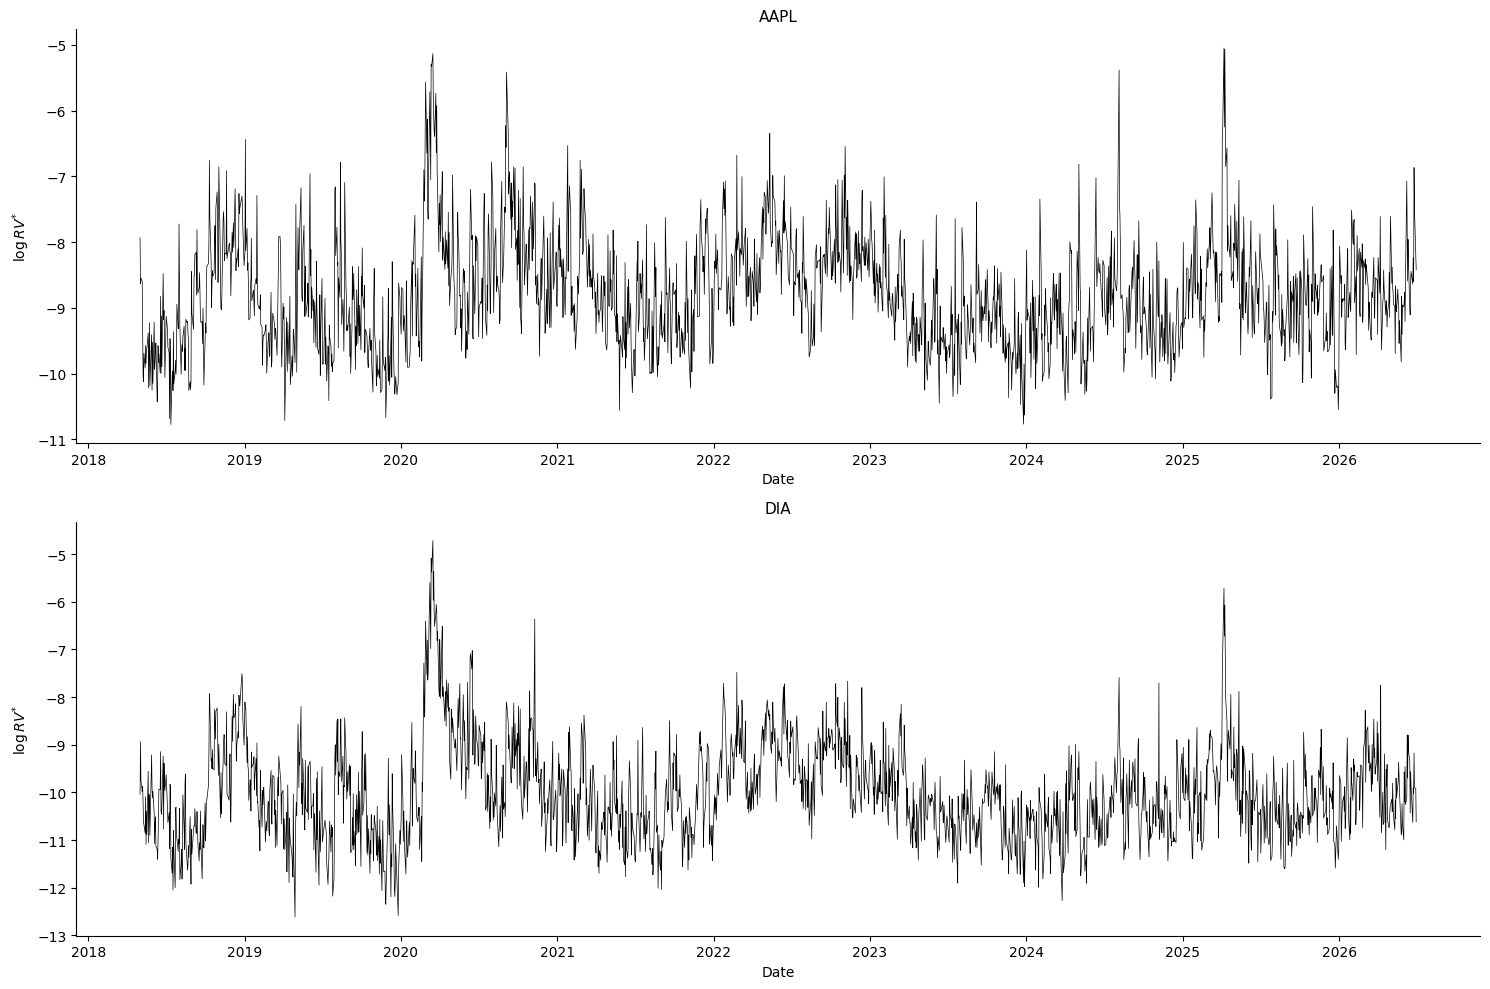

In [ ]:
# Fitted whole-day variance RV*
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
HL_TICKERS = ["AAPL", "DIA"]

def _hl_path(tick):
    return DATA_DIR / tick / f"{tick}_{RV2_FREQ}_{MU0_FREQ}_{TRIM_PCT}_{TRIM_R1}_{TRIM_RV2}_hl.parquet"

hl_lazy = {t: pl.scan_parquet(_hl_path(t)) for t in HL_TICKERS}

nrows, ncols = 2, 1
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 10))
axf = axes.flatten()

for i, tick in enumerate(HL_TICKERS):
    df = hl_lazy[tick].select("date", "RV_star").sort("date").collect()
    x, y = df["date"].to_numpy(), np.log(df["RV_star"])

    def _draw(ax):
        ax.plot(x, y, color="black", linewidth=0.5)
        ax.set_title(tick, fontsize=11)
        ax.set_xlabel("Date")
        ax.set_ylabel(r"$\log RV^{*}$")

    _draw(axf[i])

    figi, axi = plt.subplots(figsize=(7, 4))
    _draw(axi)
    sns.despine(fig=figi)
    figi.tight_layout()
    figi.savefig(FIGURES_DIR / f"{tick}_hl.pdf")
    plt.close(figi)

for j in range(len(HL_TICKERS), nrows * ncols):
    axf[j].set_visible(False)
sns.despine(fig=fig)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "ALL_hl.pdf")
plt.show()

#### Kitchen sink

Tests of the identifying assumptions for the `Technology` stocks and the `ETFs`.

In [ ]:
from math import erfc, exp, sqrt, pi

TEST_TICKERS = TICKERS_BY_SECTOR["Technology"] + TICKERS_BY_SECTOR["ETFs"]

def chi2_sf_5(x):
    s = x / 2.0
    return erfc(sqrt(s)) + exp(-s) * (2 * sqrt(s) + (4 / 3) * s ** 1.5) / sqrt(pi)

def white_wald_pvalue(y, X, k_test=5):
    XtX_inv = np.linalg.inv(X.T @ X)
    b = XtX_inv @ (X.T @ y)
    u = y - X @ b
    V = XtX_inv @ (X.T * (u ** 2)) @ X @ XtX_inv
    bs, Vs = b[-k_test:], V[-k_test:, -k_test:]
    return chi2_sf_5(float(bs @ np.linalg.inv(Vs) @ bs))

def design(df):
    Z = np.column_stack([np.log(df["rv2_lag"].to_numpy()),
                         *[(df["wd"].to_numpy() == d).astype(float) for d in (1, 2, 3, 4)]])
    return np.column_stack([np.ones(len(Z)), Z])

test_rows = []
for tick in TEST_TICKERS:
    df = (pl.read_parquet(_hl_path(tick)).select("date", "r1sq", "RV2", "RV_star")
            .join(_rv2(tick, MU0_FREQ, 0).rename({"RV2": "RV2_mu0"}), on="date")
            .sort("date")
            .with_columns(pl.col("RV2").shift(1).alias("rv2_lag"),
                          pl.col("date").dt.weekday().alias("wd")))

    n0 = df.height
    drop_dates = (set(df.sort("r1sq", descending=True).head(round(TRIM_PCT * TRIM_R1 * n0))["date"].to_list())
                  | set(df.sort("RV2", descending=True).head(round(TRIM_PCT * TRIM_RV2 * n0))["date"].to_list()))

    dfl = df.drop_nulls("rv2_lag")

    # Panel A: first kitchen sink, log(r1^2/RV2) on Z_t, truncated at r1 = 0
    d13 = dfl.filter(pl.col("r1sq") > 0)
    p_A = white_wald_pvalue(np.log((d13["r1sq"] / d13["RV2"]).to_numpy()), design(d13))

    # Panel B ratios: RV* / (r1^2 + RV^(15m)) by RV2_{t-1}-quintile and by weekday, trimmed
    d14 = dfl.filter(~pl.col("date").is_in(list(drop_dates)))
    proxy, rvstar = (d14["r1sq"] + d14["RV2_mu0"]).to_numpy(), d14["RV_star"].to_numpy()
    lag, wd = d14["rv2_lag"].to_numpy(), d14["wd"].to_numpy()
    qidx = np.searchsorted(np.quantile(lag, [0.2, 0.4, 0.6, 0.8]), lag)
    ratios_q = [rvstar[qidx == j].sum() / proxy[qidx == j].sum() for j in range(5)]
    ratios_d = [rvstar[wd == d].sum() / proxy[wd == d].sum() for d in (1, 2, 3, 4, 5)]

    # Panel B p-value: second kitchen sink, log(RV*/(r1^2 + RV^(15m))) on Z_t, full sample
    p_B = white_wald_pvalue(np.log(dfl["RV_star"].to_numpy() / (dfl["r1sq"] + dfl["RV2_mu0"]).to_numpy()),
                            design(dfl))

    test_rows.append({"ticker": tick, "p_A": round(p_A, 3),
                      **{f"q{j + 1}": round(r, 2) for j, r in enumerate(ratios_q)},
                      **{d: round(r, 2) for d, r in zip(["Mon", "Tue", "Wed", "Thu", "Fri"], ratios_d)},
                      "p_B": round(p_B, 3)})

tests_tbl = pl.DataFrame(test_rows)
tests_tbl.write_csv(TABLES_DIR / "hl_assumption_tests.csv")
with pl.Config(tbl_cols=-1):
    print(tests_tbl)

shape: (9, 13)
┌─────┬─────┬─────┬──────┬──────┬──────┬──────┬──────┬──────┬──────┬──────┬──────┬───────┐
│ tic ┆ p_A ┆ q1  ┆ q2   ┆ q3   ┆ q4   ┆ q5   ┆ Mon  ┆ Tue  ┆ Wed  ┆ Thu  ┆ Fri  ┆ p_B   │
│ ker ┆ --- ┆ --- ┆ ---  ┆ ---  ┆ ---  ┆ ---  ┆ ---  ┆ ---  ┆ ---  ┆ ---  ┆ ---  ┆ ---   │
│ --- ┆ f64 ┆ f64 ┆ f64  ┆ f64  ┆ f64  ┆ f64  ┆ f64  ┆ f64  ┆ f64  ┆ f64  ┆ f64  ┆ f64   │
│ str ┆     ┆     ┆      ┆      ┆      ┆      ┆      ┆      ┆      ┆      ┆      ┆       │
╞═════╪═════╪═════╪══════╪══════╪══════╪══════╪══════╪══════╪══════╪══════╪══════╪═══════╡
│ AAP ┆ 0.0 ┆ 1.0 ┆ 1.04 ┆ 0.97 ┆ 1.06 ┆ 0.97 ┆ 0.93 ┆ 1.03 ┆ 1.05 ┆ 1.03 ┆ 0.98 ┆ 0.0   │
│ L   ┆     ┆ 4   ┆      ┆      ┆      ┆      ┆      ┆      ┆      ┆      ┆      ┆       │
│ CRM ┆ 0.0 ┆ 1.1 ┆ 0.96 ┆ 0.93 ┆ 0.95 ┆ 1.05 ┆ 1.01 ┆ 0.98 ┆ 1.01 ┆ 0.96 ┆ 1.05 ┆ 0.0   │
│     ┆ 22  ┆     ┆      ┆      ┆      ┆      ┆      ┆      ┆      ┆      ┆      ┆       │
│ CSC ┆ 0.1 ┆ 0.9 ┆ 1.0  ┆ 0.95 ┆ 1.01 ┆ 1.02 ┆ 0.95 ┆ 1.05 ┆ 1.01 ┆ 0.92 ┆

### Subsection

The objective of this subsection is learning `Chinese.`
1. first
2. second
3. third

In [ ]:
print("Example")

Example
